# Диагностика стадий развития болезни Альцгеймера при помощи 3D CNN






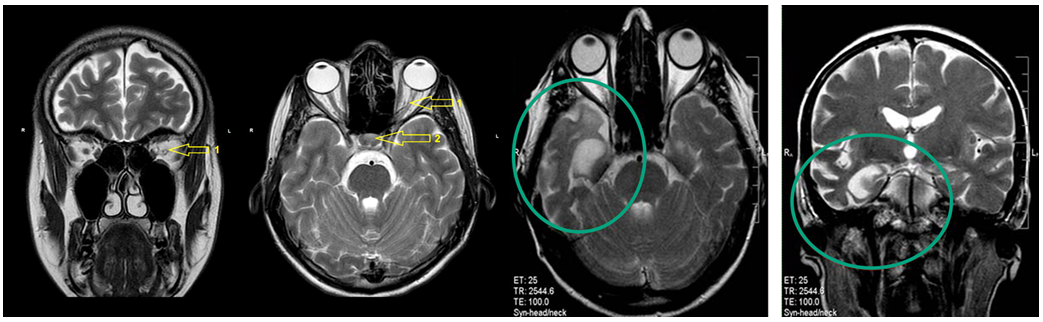

# Конфигурация и импорты

In [27]:
import gc
import os
import copy
import random

import numpy as np
import pandas as pd
import cv2
from PIL import Image
from skimage.transform import resize
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms.functional as F
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.utils.data import DataLoader, TensorDataset
from torch.cuda.amp import autocast, GradScaler
from torchvision.models.video import r3d_18, R3D_18_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    f1_score, precision_score, recall_score, roc_auc_score,
)
from imblearn.over_sampling import RandomOverSampler

# Необязательные зависимости -- ноутбук работает и без них
try:
    from torchsummary import summary
    HAS_TORCHSUMMARY = True
except ImportError:
    HAS_TORCHSUMMARY = False

try:
    from torchcam.methods import GradCAM
    HAS_TORCHCAM = True
except ImportError:
    HAS_TORCHCAM = False


In [28]:
CONFIG = {
    'new_h': 80,
    'new_w': 80,
    'target_depth': 60,            
    'majority_class': 'Non Demented',
    'majority_class_cap': 230,     
                                   
    'batch_size': 4,
    'lr_head': 1e-4,               
    'lr_finetune': 1e-5,           
    'weight_decay': 1e-4,
    'epochs_phase1': 10,
    'epochs_phase2': 10,
    'early_stopping_patience': 5,
    'model_path': 'model_alzheimer_3dcnn.pth',
    'seed': 42,
}

new_h, new_w = CONFIG['new_h'], CONFIG['new_w']
target_depth = CONFIG['target_depth']
model_path = CONFIG['model_path']

random.seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
torch.manual_seed(CONFIG['seed'])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Используемое устройство: {device}')


Используемое устройство: cpu


# Загрузка датасета

In [29]:
dataset_kaggle_path = kagglehub.dataset_download('ninadaithal/imagesoasis')
folder = os.listdir(dataset_kaggle_path)[0]
dataset_path = os.path.join(dataset_kaggle_path, str(folder))
del dataset_kaggle_path
gc.collect()


130

# Предобработка данных

Формат имени снимков
1. OAS1_0308_MR1_mpr-1_100.jpg
2. OAS1 - название проекта
3. 0308 - идентификатор пациента
4. MR1_mpr-1 - номер посещения пациента
5. 100 - номер среза. У всех есть срезы от 100 до 160 (в сумме 61 снимок/срез)


In [30]:
data = []
for stage_name in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, stage_name)
    for img_file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_file)
        data.append({
            "Path": img_path,
            'Name': img_file,
            "Class": stage_name
        })

df = pd.DataFrame(data)
df = df.sort_values('Name')
del data, dataset_path
gc.collect()


0

In [31]:
with Image.open(df.iloc[0, 0]) as img:  
    width, height = img.size
    img_array = np.array(img)
    print(np.array(img)[np.newaxis, ...].shape)
print(f'path: {df.iloc[0, 0]}, resolution: {width}x{height}')
del img_array
gc.collect()


(1, 248, 496, 3)
path: /kaggle/input/datasets/ninadaithal/imagesoasis/Data/Non Demented/OAS1_0001_MR1_mpr-1_100.jpg, resolution: 496x248


0

In [32]:
def normalize_depth(volume, depth):
    """Приводит 3D-объём (D, H, W) к фиксированному числу срезов depth."""
    d = volume.shape[0]
    if d == depth:
        return volume
    if d > depth:
        start = (d - depth) // 2
        return volume[start:start + depth]
    pad_before = (depth - d) // 2
    pad_after = depth - d - pad_before
    return np.pad(volume, ((pad_before, pad_after), (0, 0), (0, 0)), mode='edge')


majority_class = CONFIG['majority_class']
majority_cap = CONFIG['majority_class_cap']

results = []
current_code, current_class, current_slices = None, None, []
class_counts = {}

for row in df.to_dict('records'):
    code_ = '_'.join(row['Name'].split('_')[:4])

    if code_ != current_code:
        if current_slices:
            under_cap = not (current_class == majority_class
                              and class_counts.get(current_class, 0) >= majority_cap)
            if under_cap:
                volume = normalize_depth(np.stack(current_slices, axis=0), target_depth)
                results.append({"Tensor": volume, "Class": current_class})
                class_counts[current_class] = class_counts.get(current_class, 0) + 1
        current_code = code_
        current_class = row['Class']
        current_slices = []

    gray_image = cv2.imread(row['Path'], cv2.IMREAD_GRAYSCALE)
    resized_image = resize(gray_image, (new_h, new_w), anti_aliasing=True, mode='reflect')
    current_slices.append(resized_image)
    current_class = row['Class']

if current_slices:
    under_cap = not (current_class == majority_class
                      and class_counts.get(current_class, 0) >= majority_cap)
    if under_cap:
        volume = normalize_depth(np.stack(current_slices, axis=0), target_depth)
        results.append({"Tensor": volume, "Class": current_class})

data = pd.DataFrame(results)
del results, current_code, current_class, current_slices, class_counts
gc.collect()


0

In [33]:
data.Tensor.iloc[0].shape

(60, 80, 80)

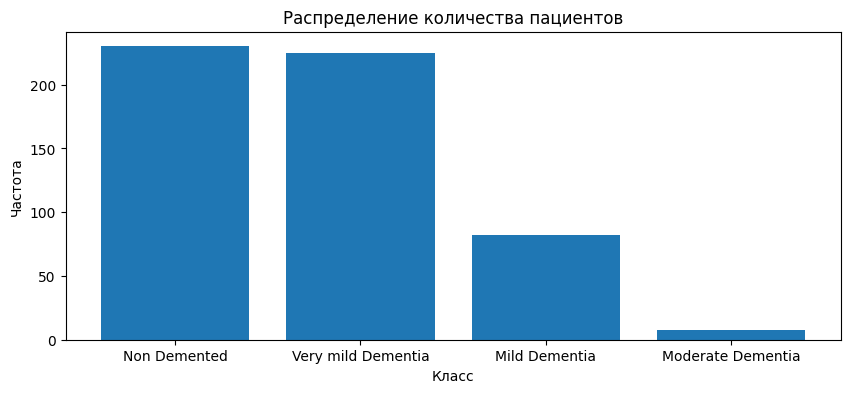

2621

In [34]:
fig = plt.figure(figsize=(10, 4))
counts = data.Class.value_counts().tolist()
names = data.Class.value_counts().index.tolist()
plt.bar(names, counts)
plt.title('Распределение количества пациентов')
plt.xlabel('Класс')
plt.ylabel('Частота')
plt.show()
del fig, counts, names
gc.collect()


In [35]:
data.loc[0]

Tensor    [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...
Class                                          Non Demented
Name: 0, dtype: object

In [36]:
data.Class.value_counts()

Class
Non Demented          230
Very mild Dementia    225
Mild Dementia          82
Moderate Dementia       8
Name: count, dtype: int64

In [37]:
def illustrate_images(df: pd.DataFrame, smp_per_class: int = 2):

    classes = df.Class.unique()
    num_classes = len(classes)

    fig = plt.figure(figsize=(num_classes * 5, smp_per_class * 3))

    for col, cls in enumerate(classes):
        samples = df[df.Class == cls].head(smp_per_class)

        for row in range(len(samples)):
            img = samples.iloc[row, 0]

            number = random.randint(0, img.shape[0] - 1)

            ax = fig.add_subplot(smp_per_class, num_classes,
                                  row * num_classes + col + 1)
            plt.axis('off')
            if row == 0:
                plt.title(cls)
            plt.imshow(img[number], cmap='gray')

    plt.tight_layout()
    plt.show()
    del classes, num_classes, fig
    gc.collect()


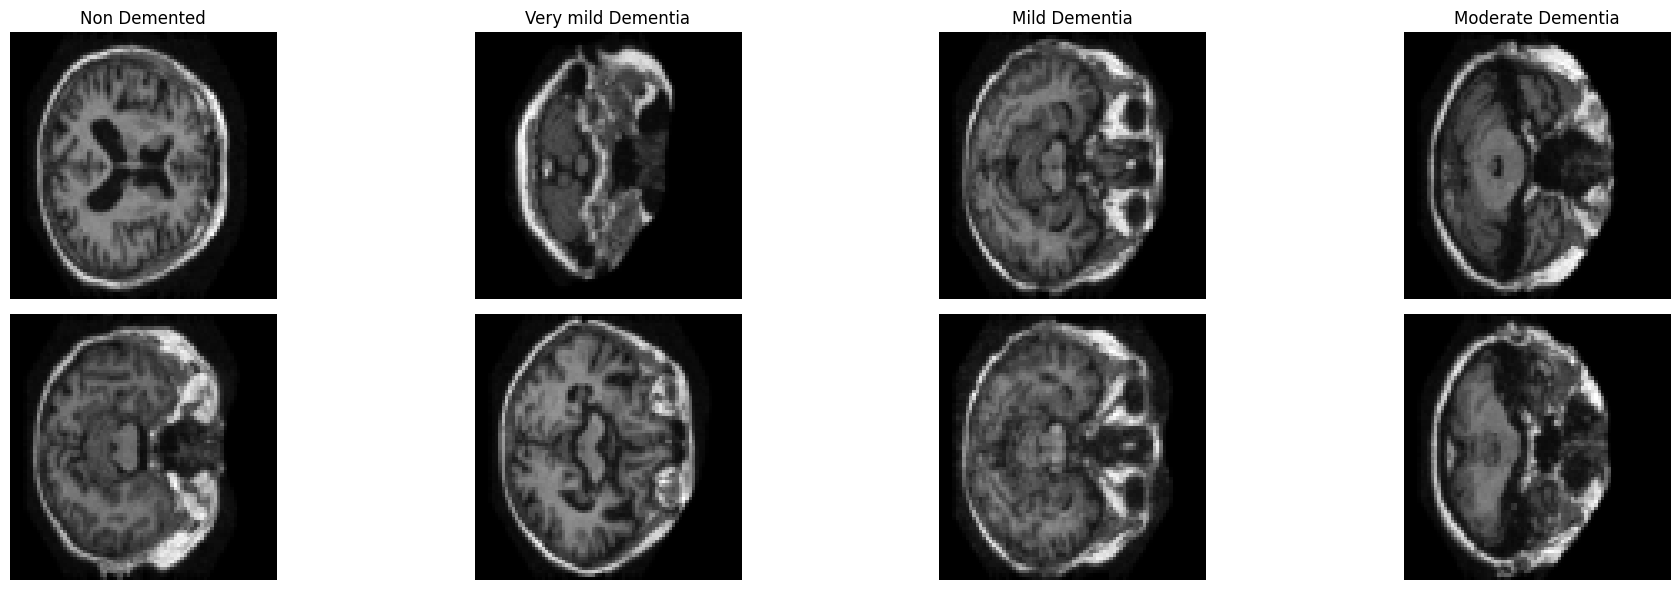

In [38]:
illustrate_images(data)

In [39]:
print(max(data.Tensor[0].flatten()), min(data.Tensor[0].flatten()))

0.9218866056339554 0.0


In [40]:
def preprocess_3d_tensor(tensor):
    tensor = np.clip(tensor, 0, 250)  
    tensor = (tensor - tensor.min()) / (tensor.max() - tensor.min())  
    return tensor


In [41]:
data['Tensor'] = data['Tensor'].apply(preprocess_3d_tensor)

In [42]:
data.to_pickle('data.pkl')  

In [43]:
data = pd.read_pickle('data.pkl')
data.head()


,Tensor,Class
0,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...",Non Demented
1,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...",Non Demented
2,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...",Non Demented
3,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...",Non Demented
4,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...",Non Demented


In [44]:
data.isna().sum()  

Tensor    0
Class     0
dtype: int64

In [45]:
data.Class.value_counts()  

Class
Non Demented          230
Very mild Dementia    225
Mild Dementia          82
Moderate Dementia       8
Name: count, dtype: int64

In [46]:
data.Tensor.iloc[0].shape

(60, 80, 80)

# Аугментация и подготовка тензоров

In [47]:
class AddGaussianNoise(nn.Module):
    def __init__(self, mean=0., std=1.):
        super().__init__()
        self.std = std
        self.mean = mean

    def forward(self, img):
        noise = torch.randn_like(img) * self.std + self.mean
        return img + noise


def augment_volume(volume, noise_std=0.005):
   
    do_flip = random.random() < 0.5
    angle = random.uniform(-90, 90)
    noiser = AddGaussianNoise(std=noise_std)

    augmented_slices = []
    for frame in volume:
        tensor = torch.from_numpy(frame).float().unsqueeze(0)  # (1, H, W)
        if do_flip:
            tensor = F.hflip(tensor)
        tensor = F.rotate(tensor, angle)
        tensor = noiser(tensor)
        augmented_slices.append(tensor)

    return torch.stack(augmented_slices, dim=0)  # (D, 1, H, W)


def augment_dataset(volumes):
    return torch.stack([augment_volume(v) for v in volumes], dim=0)  # (N, D, 1, H, W)


In [48]:
data = pd.read_pickle('data.pkl')

In [49]:
classes = sorted(data.Class.unique())
dict_class = {cls: i for i, cls in enumerate(classes)}
dict_class


{'Mild Dementia': 0,
 'Moderate Dementia': 1,
 'Non Demented': 2,
 'Very mild Dementia': 3}

In [50]:
X, y = data.Tensor.tolist(), [dict_class[i] for i in data.Class.tolist()]
X, y = np.array(X), np.array(y)
del data
gc.collect()


14930

In [51]:
ros = RandomOverSampler(random_state=CONFIG['seed'])
X_rsmp, y_rsmp = ros.fit_resample(X.reshape(len(X), -1), y)
X_rsmp = X_rsmp.reshape(-1, target_depth, new_h, new_w)
del X, y
gc.collect()


0

In [52]:
X_train, X_test_val, y_train, y_test_val = train_test_split(
    X_rsmp, y_rsmp, test_size=0.3, stratify=y_rsmp, random_state=CONFIG['seed'])
X_test, X_val, y_test, y_val = train_test_split(
    X_test_val, y_test_val, test_size=0.5, stratify=y_test_val, random_state=CONFIG['seed'])

del X_rsmp, y_rsmp
gc.collect()


X_train_tensor = augment_dataset(X_train)               # (N, D, 1, H, W)
X_train_tensor = torch.transpose(X_train_tensor, 1, 2).float()  # -> (N, 1, D, H, W)
torch.save(X_train_tensor, 'X_train_tensor.pth')
del X_train_tensor
gc.collect()

X_val_tensor = torch.tensor(X_val).unsqueeze(1).float()  # (N, 1, D, H, W), без аугментации
torch.save(X_val_tensor, 'X_val_tensor.pth')
del X_val_tensor
gc.collect()

X_test_tensor = torch.tensor(X_test).unsqueeze(1).float()  # (N, 1, D, H, W), без аугментации
torch.save(X_test_tensor, 'X_test_tensor.pth')
del X_test_tensor
gc.collect()

y_train_tensor = torch.tensor(y_train).long()
torch.save(y_train_tensor, 'y_train_tensor.pth')
del y_train_tensor
gc.collect()

y_val_tensor = torch.tensor(y_val).long()
torch.save(y_val_tensor, 'y_val_tensor.pth')
del y_val_tensor
gc.collect()

y_test_tensor = torch.tensor(y_test).long()
torch.save(y_test_tensor, 'y_test_tensor.pth')
del y_test_tensor
gc.collect()

del X_train, X_test, X_test_val, y_train, y_test_val, y_val, y_test
gc.collect()


0

In [53]:
def train_dataset_loader():
    X_train_tensor = torch.load('X_train_tensor.pth')
    y_train_tensor = torch.load('y_train_tensor.pth')
    train_ds = TensorDataset(X_train_tensor, y_train_tensor)
    return DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True)


def val_dataset_loader():
    X_val_tensor = torch.load('X_val_tensor.pth')
    y_val_tensor = torch.load('y_val_tensor.pth')
    val_ds = TensorDataset(X_val_tensor, y_val_tensor)
    return DataLoader(val_ds, batch_size=CONFIG['batch_size'], shuffle=False)


def test_dataset_loader():
    X_test_tensor = torch.load('X_test_tensor.pth')
    y_test_tensor = torch.load('y_test_tensor.pth')
    test_ds = TensorDataset(X_test_tensor, y_test_tensor)
    return DataLoader(test_ds, batch_size=CONFIG['batch_size'], shuffle=False)


# Архитектура сети

In [54]:
model = r3d_18(weights=None)  
state_dict = torch.load('/kaggle/input/datasets/yargor/r3d-18-b3b3357e/r3d_18-b3b3357e.pth', map_location='cpu')
model.load_state_dict(state_dict)


<All keys matched successfully>

In [55]:
import torch
import torch.nn as nn
from torchvision.models.video import r3d_18

class AlzheimerNet3D(nn.Module):

    def __init__(self, num_classes=4, weights_path=None):
        super().__init__()

        self.backbone = r3d_18(weights=None)
        
        if weights_path is not None:
            state_dict = torch.load(weights_path, map_location='cpu')
            self.backbone.load_state_dict(state_dict)
            print(f"Веса загружены из: {weights_path}")
        else:
            print("Веса не загружены. Модель инициализирована случайно.")
        
        self.backbone.stem[0] = nn.Conv3d(
            1, 64, kernel_size=(7, 7, 7),
            stride=(3, 3, 3), padding=(2, 2, 2), bias=False
        )
        
        # Заменяем классификатор
        self.backbone.fc = nn.Linear(
            self.backbone.fc.in_features, num_classes
        )

    def forward(self, x):
        return self.backbone(x)


def set_phase1_trainable(model):
    for name, param in model.named_parameters():
        param.requires_grad = ('stem.0' in name) or ('fc' in name)


def set_phase2_trainable(model):
    for param in model.parameters():
        param.requires_grad = True

weights_path = '/kaggle/input/datasets/yargor/r3d-18-b3b3357e/r3d_18-b3b3357e.pth'  # ← ПОДСТАВЬТЕ ВАШ ПУТЬ

model = AlzheimerNet3D(
    num_classes=len(dict_class),
    weights_path=weights_path
).to(device)

if HAS_TORCHSUMMARY:
    summary(model, input_size=(1, target_depth, new_h, new_w))
else:
    n_params = sum(p.numel() for p in model.parameters())
    print(f'Модель создана. Всего параметров: {n_params:,}')

Веса загружены из: /kaggle/input/datasets/yargor/r3d-18-b3b3357e/r3d_18-b3b3357e.pth
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv3d-1       [-1, 64, 20, 26, 26]          21,952
       BatchNorm3d-2       [-1, 64, 20, 26, 26]             128
              ReLU-3       [-1, 64, 20, 26, 26]               0
      Conv3DSimple-4       [-1, 64, 20, 26, 26]         110,592
       BatchNorm3d-5       [-1, 64, 20, 26, 26]             128
              ReLU-6       [-1, 64, 20, 26, 26]               0
      Conv3DSimple-7       [-1, 64, 20, 26, 26]         110,592
       BatchNorm3d-8       [-1, 64, 20, 26, 26]             128
              ReLU-9       [-1, 64, 20, 26, 26]               0
       BasicBlock-10       [-1, 64, 20, 26, 26]               0
     Conv3DSimple-11       [-1, 64, 20, 26, 26]         110,592
      BatchNorm3d-12       [-1, 64, 20, 26, 26]             128
             ReLU-

# Обучение

In [56]:
def run_training_phase(model, phase_name, num_epochs, lr, history, best_state):
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=CONFIG['weight_decay'],
    )
    criterion = nn.CrossEntropyLoss()
    scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=max(2, num_epochs // 3))
    scaler = GradScaler(enabled=(device.type == 'cuda'))

    epochs_without_improvement = 0

    for epoch in range(num_epochs):
        model.train()
        train_loader = train_dataset_loader()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with autocast(enabled=(device.type == 'cuda')):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = 100 * correct / total
        del train_loader
        gc.collect()

        model.eval()
        val_loader = val_dataset_loader()
        running_val_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                running_val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss = running_val_loss / total
        val_acc = 100 * correct / total
        del val_loader
        gc.collect()

        scheduler.step(epoch)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        improved = val_loss < best_state['loss']
        if improved:
            best_state['loss'] = val_loss
            best_state['weights'] = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), model_path)
            epochs_without_improvement = 0
            marker = ' (новая лучшая модель сохранена)'
        else:
            epochs_without_improvement += 1
            marker = ''

        print(f"[{phase_name}] Эпоха {epoch + 1}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% | "
              f"LR: {optimizer.param_groups[0]['lr']:.2e}{marker}")

        if epochs_without_improvement >= CONFIG['early_stopping_patience']:
            print(f"[{phase_name}] Early stopping: нет улучшений "
                  f"{CONFIG['early_stopping_patience']} эпох подряд.")
            break

    if best_state['weights'] is not None:
        model.load_state_dict(best_state['weights'])
    return model


## Фаза 1: обучение головы (backbone заморожен)

In [57]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_state = {'loss': float('inf'), 'weights': None}

set_phase1_trainable(model)
model = run_training_phase(
    model, phase_name='Фаза 1 (голова)',
    num_epochs=CONFIG['epochs_phase1'], lr=CONFIG['lr_head'],
    history=history, best_state=best_state,
)


/tmp/ipykernel_59/3906364925.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(device.type == 'cuda'))
/tmp/ipykernel_59/3906364925.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == 'cuda')):


[Фаза 1 (голова)] Эпоха 1/10 | Train Loss: 1.4103 Acc: 28.26% | Val Loss: 1.3779 Acc: 29.71% | LR: 1.00e-04 (новая лучшая модель сохранена)
[Фаза 1 (голова)] Эпоха 2/10 | Train Loss: 1.3177 Acc: 36.80% | Val Loss: 1.3203 Acc: 39.13% | LR: 7.50e-05 (новая лучшая модель сохранена)
[Фаза 1 (голова)] Эпоха 3/10 | Train Loss: 1.2651 Acc: 47.36% | Val Loss: 1.2516 Acc: 47.83% | LR: 2.50e-05 (новая лучшая модель сохранена)
[Фаза 1 (голова)] Эпоха 4/10 | Train Loss: 1.2199 Acc: 51.09% | Val Loss: 1.2395 Acc: 46.38% | LR: 1.00e-04 (новая лучшая модель сохранена)
[Фаза 1 (голова)] Эпоха 5/10 | Train Loss: 1.1954 Acc: 50.31% | Val Loss: 1.1961 Acc: 42.75% | LR: 7.50e-05 (новая лучшая модель сохранена)
[Фаза 1 (голова)] Эпоха 6/10 | Train Loss: 1.1448 Acc: 53.42% | Val Loss: 1.1814 Acc: 51.45% | LR: 2.50e-05 (новая лучшая модель сохранена)
[Фаза 1 (голова)] Эпоха 7/10 | Train Loss: 1.1117 Acc: 58.85% | Val Loss: 1.1482 Acc: 51.45% | LR: 1.00e-04 (новая лучшая модель сохранена)
[Фаза 1 (голова)] Эп

## Фаза 2: fine-tuning всей сети

In [58]:
set_phase2_trainable(model)
best_state['loss'] = float('inf')  

model = run_training_phase(
    model, phase_name='Фаза 2 (fine-tuning)',
    num_epochs=CONFIG['epochs_phase2'], lr=CONFIG['lr_finetune'],
    history=history, best_state=best_state,
)

torch.save(model.state_dict(), model_path)
print(f'Финальные веса сохранены в {model_path}')


/tmp/ipykernel_59/3906364925.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(device.type == 'cuda'))
/tmp/ipykernel_59/3906364925.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == 'cuda')):


[Фаза 2 (fine-tuning)] Эпоха 1/10 | Train Loss: 0.9226 Acc: 63.51% | Val Loss: 0.6926 Acc: 76.81% | LR: 1.00e-05 (новая лучшая модель сохранена)
[Фаза 2 (fine-tuning)] Эпоха 2/10 | Train Loss: 0.6951 Acc: 76.40% | Val Loss: 0.5989 Acc: 81.88% | LR: 7.50e-06 (новая лучшая модель сохранена)
[Фаза 2 (fine-tuning)] Эпоха 3/10 | Train Loss: 0.5416 Acc: 82.45% | Val Loss: 0.5870 Acc: 76.81% | LR: 2.50e-06 (новая лучшая модель сохранена)
[Фаза 2 (fine-tuning)] Эпоха 4/10 | Train Loss: 0.4199 Acc: 89.29% | Val Loss: 0.6256 Acc: 78.26% | LR: 1.00e-05
[Фаза 2 (fine-tuning)] Эпоха 5/10 | Train Loss: 0.3703 Acc: 90.99% | Val Loss: 0.5549 Acc: 77.54% | LR: 7.50e-06 (новая лучшая модель сохранена)
[Фаза 2 (fine-tuning)] Эпоха 6/10 | Train Loss: 0.3070 Acc: 92.86% | Val Loss: 0.5207 Acc: 78.99% | LR: 2.50e-06 (новая лучшая модель сохранена)
[Фаза 2 (fine-tuning)] Эпоха 7/10 | Train Loss: 0.2558 Acc: 93.32% | Val Loss: 0.4952 Acc: 81.16% | LR: 1.00e-05 (новая лучшая модель сохранена)
[Фаза 2 (fine-tun

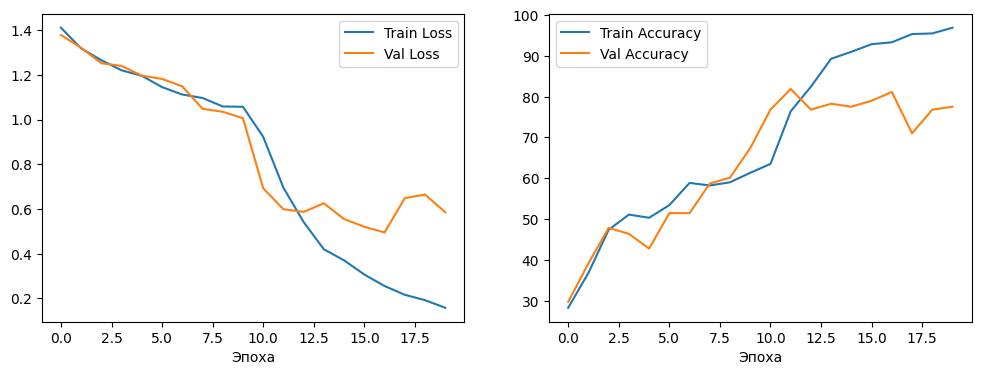

In [59]:
def plot_metrics(history):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.xlabel('Эпоха')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy')
    plt.plot(history['val_acc'], label='Val Accuracy')
    plt.xlabel('Эпоха')
    plt.legend()

    plt.show()


plot_metrics(history)


# Оценка на тестовой выборке

Test Accuracy:  0.8116
F1 (macro):     0.8043
Precision (macro): 0.8093
Recall (macro):    0.8120
ROC-AUC (macro, OvR): 0.9693


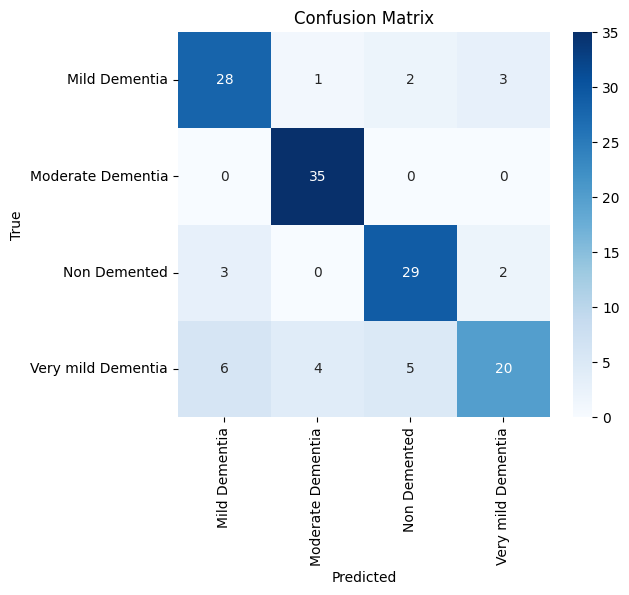

Classification Report:

                    precision    recall  f1-score   support

     Mild Dementia       0.76      0.82      0.79        34
 Moderate Dementia       0.88      1.00      0.93        35
      Non Demented       0.81      0.85      0.83        34
Very mild Dementia       0.80      0.57      0.67        35

          accuracy                           0.81       138
         macro avg       0.81      0.81      0.80       138
      weighted avg       0.81      0.81      0.80       138



In [60]:
model.eval()
y_true, y_pred, y_proba = [], [], []
label_map = {v: k for k, v in dict_class.items()}

test_loader = test_dataset_loader()

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)

        y_pred.extend(preds)
        y_proba.extend(probs)
        y_true.extend(y_batch.numpy())

del test_loader
gc.collect()

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_proba = np.array(y_proba)

test_acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall = recall_score(y_true, y_pred, average='macro', zero_division=0)

try:
    roc_auc = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
except ValueError as e:

    roc_auc = float('nan')
    print(f'ROC-AUC не удалось посчитать: {e}')

print(f"Test Accuracy:  {test_acc:.4f}")
print(f"F1 (macro):     {f1:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro):    {recall:.4f}")
print(f"ROC-AUC (macro, OvR): {roc_auc:.4f}")

cm = confusion_matrix(y_true, y_pred)
present_labels = sorted(np.unique(np.concatenate([y_true, y_pred])))
tick_labels = [label_map[i] for i in present_labels]

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=tick_labels, yticklabels=tick_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=tick_labels, zero_division=0))


## Литература

1. https://link.springer.com/article/10.1007/s10278-025-01402-z
2. https://sci-hub.ru/https://doi.org/10.1162/jocn.2007.19.9.1498


In [61]:
import kagglehub, os, shutil

# Собираем веса в отдельную папку
os.makedirs('my_model', exist_ok=True)
shutil.copy(CONFIG['model_path'], 'my_model/model_alzheimer_3dcnn.pth')

# Формат handle: '<username>/<название-модели>/<фреймворк>/<вариация>'
handle = 'yargor/alzheimer-3d-cnn/pyTorch/r3d18-finetuned'

kagglehub.model_upload(
    handle,
    'my_model',
    license_name='MIT',
    version_notes='Initial fine-tuned checkpoint',
)

Uploading Model https://api.kaggle.com/models/yargor/alzheimer-3d-cnn/pyTorch/r3d18-finetuned ...


ConnectionError: HTTPSConnectionPool(host='api.kaggle.com', port=443): Max retries exceeded with url: /v1/models.ModelApiService/GetModel (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x79fa49f94ef0>: Failed to resolve 'api.kaggle.com' ([Errno -3] Temporary failure in name resolution)"))

In [ ]:
!ls -lh model_alzheimer_3dcnn.pth

In [ ]:
import os
print(os.path.exists('/kaggle/working/model_alzheimer_3dcnn.pth'))
os.listdir('./')